Лабораторна робота №6

Виконав: Верещака Олександр ПР-2-2
Варіант №1

### Хід роботи


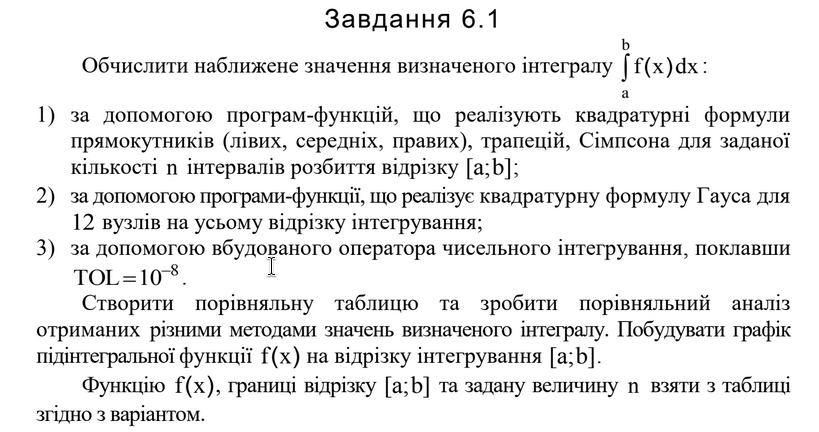

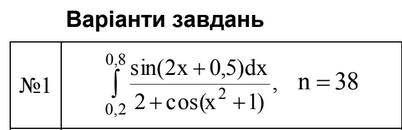

Порівняльна таблиця результатів інтегрування:
---------------------------------------------------------------------------
               Метод  Значення інтеграла  Абсолютна похибка
   Ліві прямокутники            0.247281       1.076294e-03
  Праві прямокутники            0.249405       1.047523e-03
Середні прямокутники            0.248365       7.192643e-06
            Трапеції            0.248343       1.438544e-05
            Сімпсона            0.248357       5.231310e-11
   Гауса (12 вузлів)            0.248357       5.551115e-17
 Вбудований оператор            0.248357       0.000000e+00
---------------------------------------------------------------------------


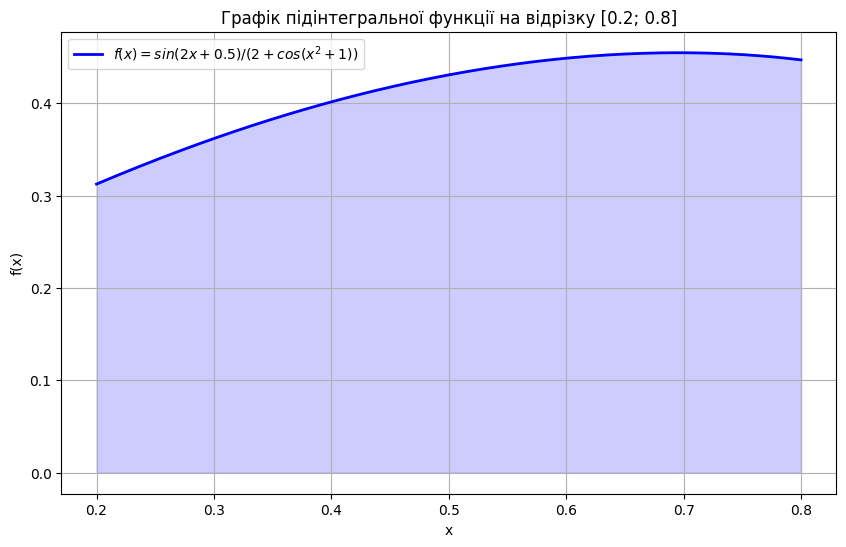

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Варіант 1)
# ==========================================
a = 0.2
b = 0.8
n = 38

def f(x):
    return np.sin(2*x + 0.5) / (2 + np.cos(x**2 + 1))

# ==========================================
# 1. Прості квадратурні формули (n = 38)
# ==========================================
h = (b - a) / n
x = np.linspace(a, b, n + 1)

# Ліві та праві прямокутники
I_left = np.sum(f(x[:-1])) * h
I_right = np.sum(f(x[1:])) * h

# Середні прямокутники
x_mid = (x[:-1] + x[1:]) / 2
I_mid = np.sum(f(x_mid)) * h

# Трапеції та Сімпсона (через базові методи)
I_trap = (I_left + I_right) / 2
I_simp = (I_trap + 2 * I_mid) / 3

# ==========================================
# 2. Метод Гауса (12 вузлів)
# ==========================================
t, w = np.polynomial.legendre.leggauss(12)

# Перехід від відрізка [-1, 1] до [a, b]
x_gauss = 0.5 * (b - a) * t + 0.5 * (b + a)
w_gauss = 0.5 * (b - a) * w

I_gauss = np.sum(w_gauss * f(x_gauss))

# ==========================================
# 3. Вбудований оператор (TOL = 10^-8)
# ==========================================
# Використовуємо функцію quad, задаючи абсолютну похибку epsabs
I_builtin, error = integrate.quad(f, a, b, epsabs=1e-8)

# ==========================================
# 4. Створення порівняльної таблиці
# ==========================================
results = {
    "Метод": [
        "Ліві прямокутники", 
        "Праві прямокутники", 
        "Середні прямокутники", 
        "Трапеції", 
        "Сімпсона", 
        "Гауса (12 вузлів)", 
        "Вбудований оператор"
    ],
    "Значення інтеграла": [
        I_left, 
        I_right, 
        I_mid, 
        I_trap, 
        I_simp, 
        I_gauss, 
        I_builtin
    ]
}

df = pd.DataFrame(results)
# Розрахунок абсолютної похибки відносно вбудованого методу
df["Абсолютна похибка"] = np.abs(df["Значення інтеграла"] - I_builtin)

print("Порівняльна таблиця результатів інтегрування:")
print("-" * 75)
print(df.to_string(index=False))
print("-" * 75)

# ==========================================
# 5. Побудова графіка
# ==========================================
x_plot = np.linspace(a, b, 200)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='$f(x) = sin(2x + 0.5) / (2 + cos(x^2 + 1))$')

# Заливка області під графіком
plt.fill_between(x_plot, y_plot, alpha=0.2, color='blue')

plt.title('Графік підінтегральної функції на відрізку [0.2; 0.8]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

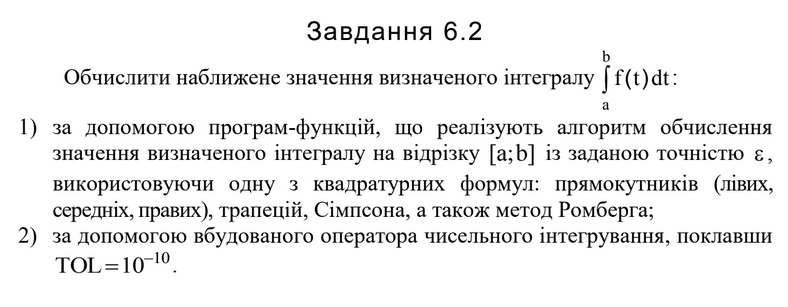

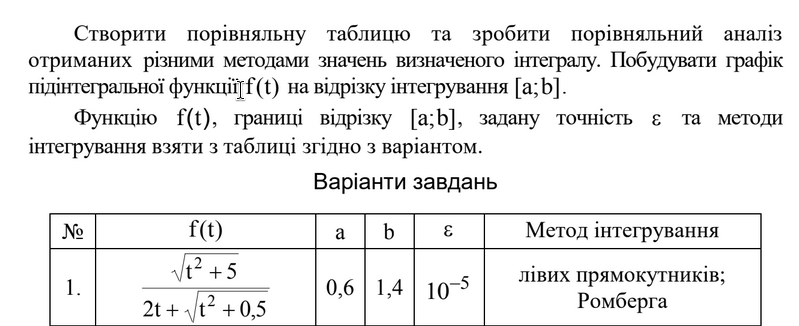

Завдання 6.2 (Варіант 1) - Порівняльна таблиця:
------------------------------------------------------------------------------------------
                           Метод  Значення інтеграла  Абсолютна похибка Кількість інтервалів (n)
               Ліві прямокутники            0.629845       5.912674e-06                    32768
                        Ромберга            0.629839       2.919319e-10                       16
Вбудований оператор (scipy.quad)            0.629839       6.992617e-15              Автоматично
------------------------------------------------------------------------------------------


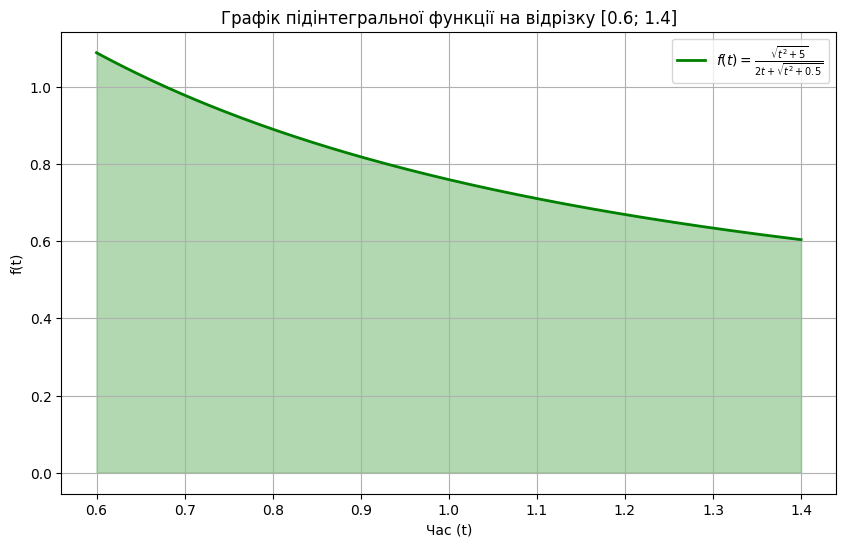

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.2, Варіант 1)
# ==========================================
a = 0.6
b = 1.4
eps = 1e-5  # Задана точність для методів
tol = 1e-10 # Точність для вбудованого оператора

def f(t):
    return np.sqrt(t**2 + 5) / (2*t + np.sqrt(t**2 + 0.5))

# ==========================================
# 1. Метод лівих прямокутників із заданою точністю eps
# ==========================================
def left_rectangles_tol(f, a, b, eps):
    n = 2 # Початкова кількість розбиттів
    I_prev = float('inf') # Початкове нескінченне значення для першого порівняння
    
    while True:
        h = (b - a) / n
        t = np.linspace(a, b, n + 1)
        # Рахуємо площу лівих прямокутників
        I_curr = np.sum(f(t[:-1])) * h
        
        # Перевірка умови закінчення (правило Рунге)
        if np.abs(I_curr - I_prev) < eps:
            return I_curr, n
        
        I_prev = I_curr
        n *= 2 # Подвоюємо кількість кроків, якщо точність не досягнута

I_left, n_left = left_rectangles_tol(f, a, b, eps)

# ==========================================
# 2. Метод Ромберга із заданою точністю eps
# ==========================================
def romberg_tol(f, a, b, eps, max_iter=20):
    R = np.zeros((max_iter, max_iter))
    # Базове наближення (метод трапецій для 1 інтервалу)
    R[0, 0] = 0.5 * (b - a) * (f(a) + f(b))
    
    for i in range(1, max_iter):
        h = (b - a) / (2**i)
        # Сума нових вузлів
        sum_f = sum(f(a + (2*k - 1)*h) for k in range(1, 2**(i-1) + 1))
        R[i, 0] = 0.5 * R[i-1, 0] + h * sum_f
        
        # Екстраполяція Річардсона
        for j in range(1, i + 1):
            R[i, j] = R[i, j-1] + (R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        
        # Перевірка точності по діагоналі матриці
        if np.abs(R[i, i] - R[i-1, i-1]) < eps:
            return R[i, i], 2**i
            
    return R[max_iter-1, max_iter-1], 2**(max_iter-1)

I_romb, n_romb = romberg_tol(f, a, b, eps)

# ==========================================
# 3. Вбудований оператор (TOL = 10^-10)
# ==========================================
I_builtin, error = integrate.quad(f, a, b, epsabs=tol)

# ==========================================
# 4. Створення порівняльної таблиці
# ==========================================
results = {
    "Метод": [
        "Ліві прямокутники", 
        "Ромберга", 
        "Вбудований оператор (scipy.quad)"
    ],
    "Значення інтеграла": [
        I_left, 
        I_romb, 
        I_builtin
    ],
    "Абсолютна похибка": [
        np.abs(I_left - I_builtin),
        np.abs(I_romb - I_builtin),
        error
    ],
    "Кількість інтервалів (n)": [
        n_left,
        n_romb,
        "Автоматично"
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.2 (Варіант 1) - Порівняльна таблиця:")
print("-" * 90)
print(df.to_string(index=False))
print("-" * 90)

# ==========================================
# 5. Побудова графіка
# ==========================================
t_plot = np.linspace(a, b, 200)
f_plot = f(t_plot)

plt.figure(figsize=(10, 6))
plt.plot(t_plot, f_plot, 'g-', linewidth=2, label=r'$f(t) = \frac{\sqrt{t^2 + 5}}{2t + \sqrt{t^2 + 0.5}}$')

# Заливка області під графіком
plt.fill_between(t_plot, f_plot, alpha=0.3, color='green')

plt.title('Графік підінтегральної функції на відрізку [0.6; 1.4]')
plt.xlabel('Час (t)')
plt.ylabel('f(t)')
plt.grid(True)
plt.legend()
plt.show()

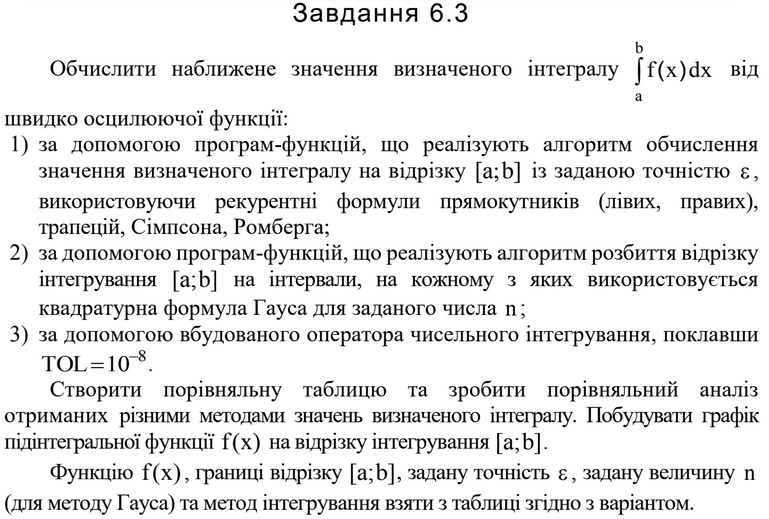

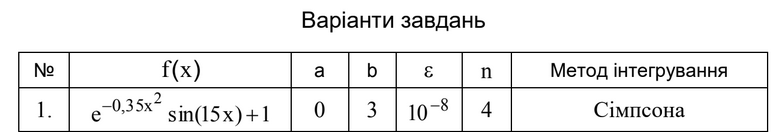

Завдання 6.3 (Варіант 1) - Швидко осцилююча функція:
-----------------------------------------------------------------------------------------------
                  Метод  Значення інтеграла  Абсолютна похибка Обчислених точок функції
               Сімпсона            3.065063       1.386042e-09                     1025
  Складений Гауса (n=4)            3.065063       2.478018e-12                      256
Вбудований (scipy.quad)            3.065063       5.423025e-11              Автоматично
-----------------------------------------------------------------------------------------------


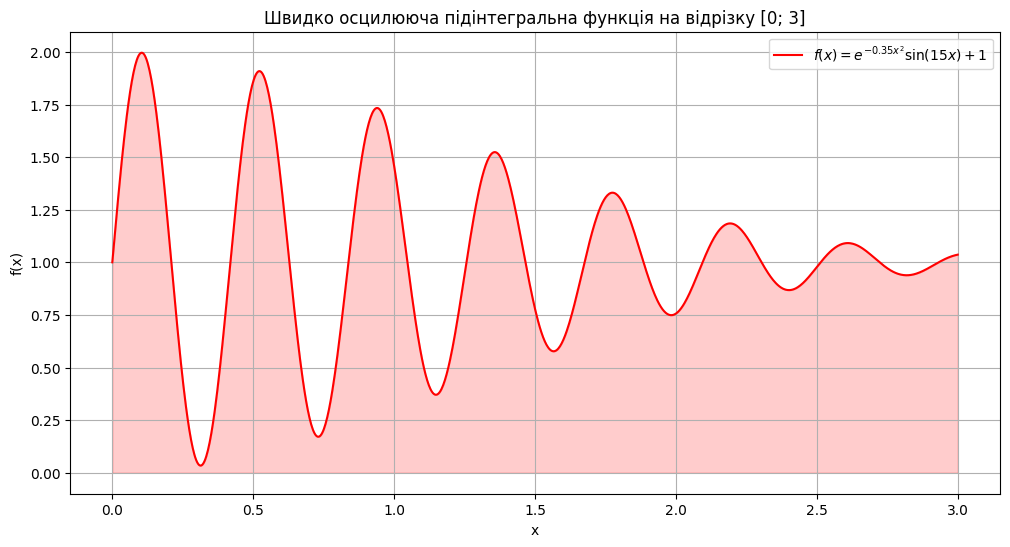

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.3, Варіант 1)
# ==========================================
a = 0.0
b = 3.0
eps = 1e-8  # Задана точність
n_gauss = 4 # Кількість вузлів для методу Гауса

def f(x):
    return np.exp(-0.35 * x**2) * np.sin(15 * x) + 1

# ==========================================
# 1. Ітераційний метод Сімпсона
# ==========================================
def simpson_tol(f, a, b, eps):
    n = 2 # Початкова кількість розбиттів (має бути парною)
    
    def calc_simpson(n_intervals):
        x = np.linspace(a, b, n_intervals + 1)
        h = (b - a) / n_intervals
        y = f(x)
        # Векторизована формула Сімпсона
        return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])
        
    I_prev = calc_simpson(n)
    
    while True:
        n *= 2
        I_curr = calc_simpson(n)
        # Оцінка похибки за правилом Рунге для методу Сімпсона (ділимо на 15)
        if np.abs(I_curr - I_prev) / 15 < eps:
            return I_curr, n
        I_prev = I_curr

I_simp, n_simp = simpson_tol(f, a, b, eps)

# ==========================================
# 2. Складена квадратурна формула Гауса (n=4 вузли)
# ==========================================
def composite_gauss_tol(f, a, b, n_nodes, eps):
    # Отримуємо стандартні вузли та ваги для відрізка [-1, 1]
    t, w = np.polynomial.legendre.leggauss(n_nodes)
    m = 1 # Початкова кількість підінтервалів
    
    def calc_composite_gauss(m_intervals):
        edges = np.linspace(a, b, m_intervals + 1)
        integral = 0
        for i in range(m_intervals):
            a_i, b_i = edges[i], edges[i+1]
            # Масштабування вузлів та ваг на локальний відрізок [a_i, b_i]
            x_i = 0.5 * (b_i - a_i) * t + 0.5 * (b_i + a_i)
            w_i = 0.5 * (b_i - a_i) * w
            integral += np.sum(w_i * f(x_i))
        return integral

    I_prev = calc_composite_gauss(m)
    
    while True:
        m *= 2
        I_curr = calc_composite_gauss(m)
        # Спрощена перевірка на збіжність
        if np.abs(I_curr - I_prev) < eps:
            return I_curr, m * n_nodes # Загальна кількість обчислених точок
        I_prev = I_curr

I_gauss, points_gauss = composite_gauss_tol(f, a, b, n_gauss, eps)

# ==========================================
# 3. Вбудований оператор (TOL = 10^-8)
# ==========================================
# Для швидко осцилюючих функцій збільшуємо ліміт розбиттів limit=200
I_builtin, error = integrate.quad(f, a, b, epsabs=eps, limit=200)

# ==========================================
# 4. Порівняльна таблиця
# ==========================================
results = {
    "Метод": [
        "Сімпсона", 
        f"Складений Гауса (n={n_gauss})", 
        "Вбудований (scipy.quad)"
    ],
    "Значення інтеграла": [
        I_simp, 
        I_gauss, 
        I_builtin
    ],
    "Абсолютна похибка": [
        np.abs(I_simp - I_builtin),
        np.abs(I_gauss - I_builtin),
        error
    ],
    "Обчислених точок функції": [
        n_simp + 1,
        points_gauss,
        "Автоматично"
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.3 (Варіант 1) - Швидко осцилююча функція:")
print("-" * 95)
print(df.to_string(index=False))
print("-" * 95)

# ==========================================
# 5. Побудова графіка
# ==========================================
# Беремо багато точок (1000), щоб графік осцилюючої функції був плавним і не "ламався"
x_plot = np.linspace(a, b, 1000)
y_plot = f(x_plot)

plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, 'r-', linewidth=1.5, label=r'$f(x) = e^{-0.35x^2} \sin(15x) + 1$')

plt.fill_between(x_plot, y_plot, alpha=0.2, color='red')

plt.title('Швидко осцилююча підінтегральна функція на відрізку [0; 3]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

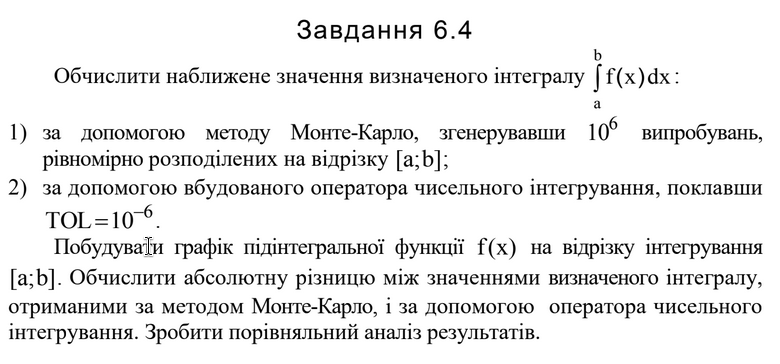

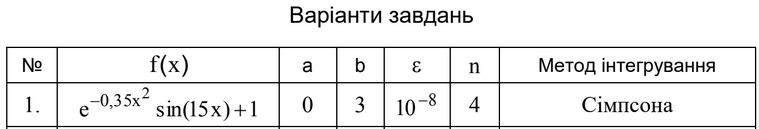

Завдання 6.4 (Варіант 1) - Невласні інтеграли 1-го роду:
--------------------------------------------------------------------------------
                  Метод  Значення інтеграла  Абсолютна похибка Ефективна межа (B)
Метод розширення межі B            1.327189       7.808994e-08               10.0
    Вбудований (a до ∞)            1.327189       5.723522e-12                  ∞
--------------------------------------------------------------------------------


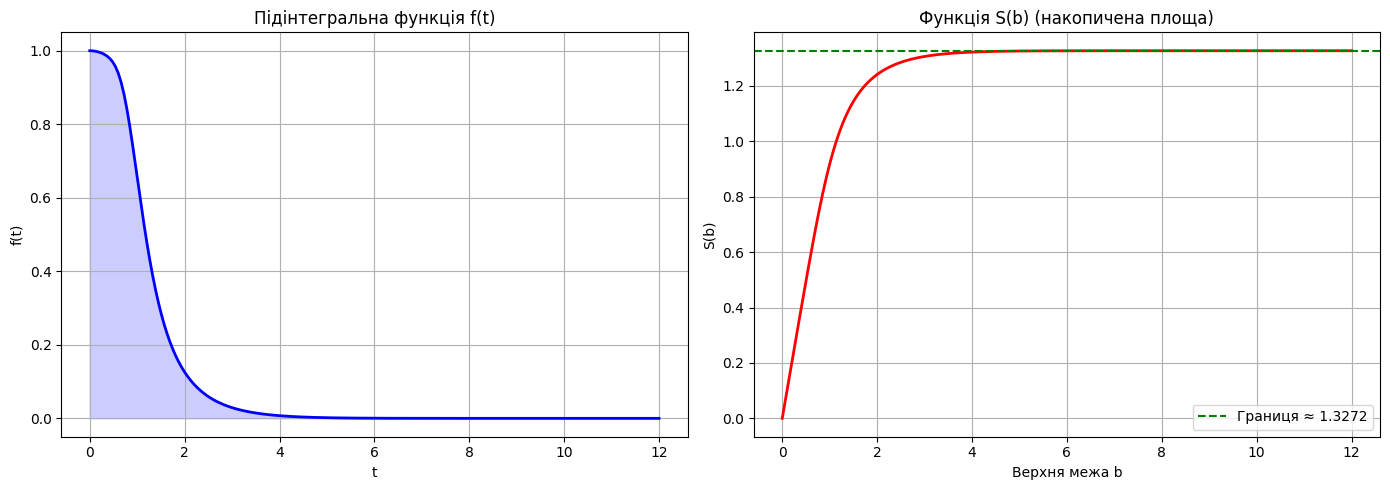

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.4, Варіант 1)
# ==========================================
a = 0.0
eps = 1e-6   # Задана точність для нашого методу
tol = 1e-10  # Точність для вбудованого оператора

def f(t):
    # Уникаємо ділення на нуль або від'ємних значень під коренем
    denominator = (t**12 + 3*t**6 + 1)**(1/5)
    return np.exp(-0.1 * t**2) / denominator

# ==========================================
# 1. Обчислення невласного інтегралу із заданою точністю eps
# ==========================================
def improper_integral_tol(f, a, eps):
    B = a + 1.0  # Початкова скінченна верхня межа
    step = 1.0   # Крок збільшення межі
    I_prev = 0.0
    
    while True:
        # Рахуємо інтеграл на скінченному відрізку [a, B]
        # Використовуємо quad для локального обчислення площі
        I_curr, _ = integrate.quad(f, a, B)
        
        # Перевіряємо, чи змінилося значення більше ніж на eps
        if np.abs(I_curr - I_prev) < eps:
            return I_curr, B # Повертаємо значення та знайдену межу "нескінченності"
            
        I_prev = I_curr
        B += step

I_custom, B_final = improper_integral_tol(f, a, eps)

# ==========================================
# 2. Вбудований оператор (TOL = 10^-10) від a до нескінченності
# ==========================================
I_builtin, error = integrate.quad(f, a, np.inf, epsabs=tol)

# ==========================================
# 3. Порівняльна таблиця
# ==========================================
results = {
    "Метод": [
        "Метод розширення межі B", 
        "Вбудований (a до ∞)"
    ],
    "Значення інтеграла": [
        I_custom, 
        I_builtin
    ],
    "Абсолютна похибка": [
        np.abs(I_custom - I_builtin),
        error
    ],
    "Ефективна межа (B)": [
        B_final,
        "∞"
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.4 (Варіант 1) - Невласні інтеграли 1-го роду:")
print("-" * 80)
print(df.to_string(index=False))
print("-" * 80)

# ==========================================
# 4. Побудова графіків f(t) та S(b)
# ==========================================
# Беремо відрізок трохи далі за знайдене B_final, щоб побачити асимптоту
t_vals = np.linspace(a, B_final + 2, 200)
f_vals = f(t_vals)

# Обчислюємо S(b) - інтеграл із змінною верхньою межею
S_vals = [integrate.quad(f, a, b)[0] for b in t_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік самої функції f(t)
ax1.plot(t_vals, f_vals, 'b-', linewidth=2)
ax1.fill_between(t_vals, f_vals, alpha=0.2, color='blue')
ax1.set_title('Підінтегральна функція f(t)')
ax1.set_xlabel('t')
ax1.set_ylabel('f(t)')
ax1.grid(True)

# Графік інтегралу зі змінною верхньою межею S(b)
ax2.plot(t_vals, S_vals, 'r-', linewidth=2)
# Додаємо горизонтальну лінію, що показує фінальне значення інтеграла (границю)
ax2.axhline(y=I_builtin, color='green', linestyle='--', label=f'Границя ≈ {I_builtin:.4f}')
ax2.set_title('Функція S(b) (накопичена площа)')
ax2.set_xlabel('Верхня межа b')
ax2.set_ylabel('S(b)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

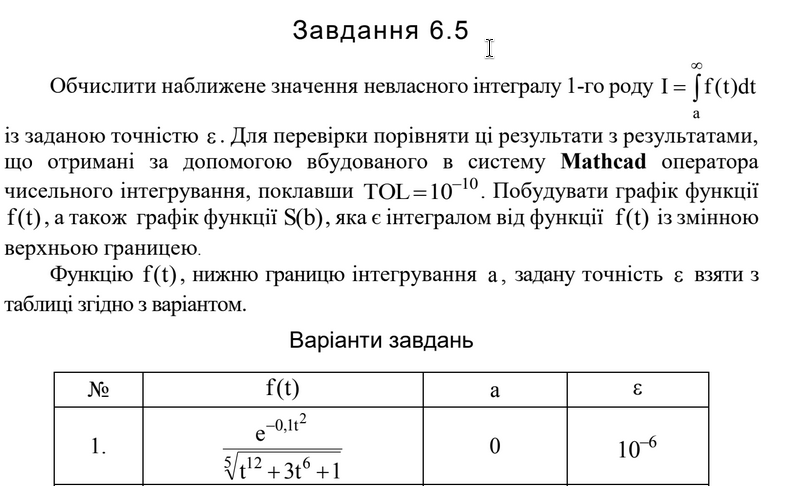

Завдання 6.5 (Варіант 1) - Невласні інтеграли 1-го роду
            Метод обчислення  Значення інтеграла  Абсолютна похибка    Верхня межа (b)
Алгоритм розширення межі (b)            1.327189       7.808994e-08               10.0
     Вбудований (від a до ∞)            1.327189       5.723522e-12 ∞ (нескінченність)


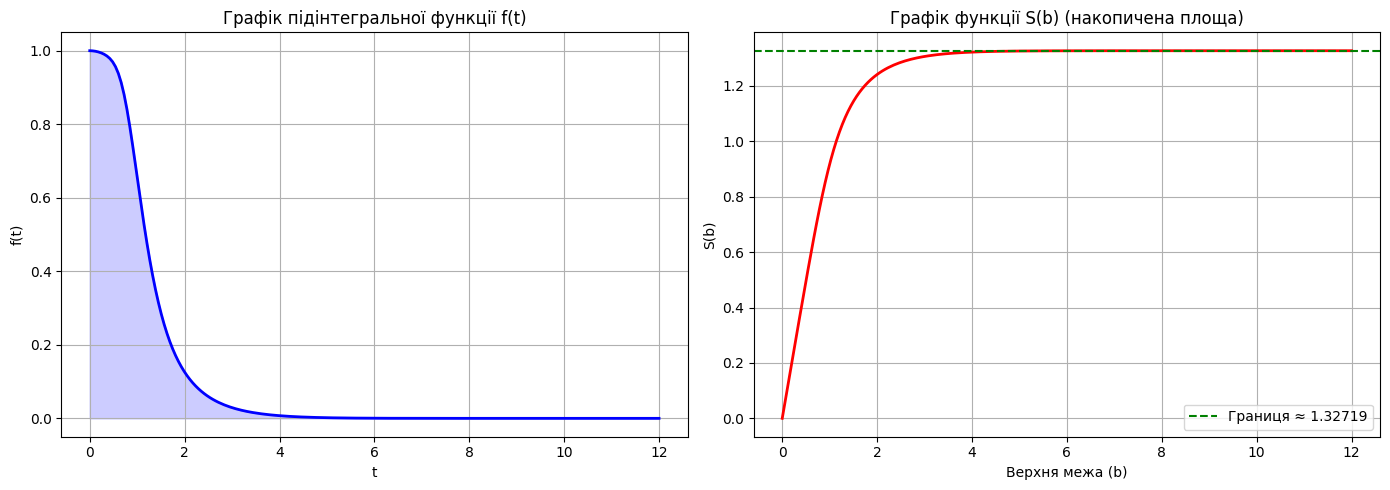

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.5, Варіант 1)
# ==========================================
a = 0.0      # Нижня границя інтегрування
eps = 1e-6   # Задана точність для нашого алгоритму
tol = 1e-10  # Точність для вбудованого оператора

def f(t):
    """Підінтегральна функція згідно з варіантом 1"""
    # Розбиваємо формулу на частини для уникнення помилок
    numerator = np.exp(-0.1 * t**2)
    denominator = (t**12 + 3*t**6 + 1)**(1/5)
    return numerator / denominator

# ==========================================
# 1. Обчислення невласного інтегралу (наш алгоритм)
# ==========================================
def improper_integral(f, a, eps):
    """
    Алгоритм обчислення невласного інтегралу 1-го роду.
    Поступово збільшуємо верхню межу b, поки додавання 
    нової площі не стане меншим за задану точність eps.
    """
    b = a + 1.0  # Початкова скінченна верхня межа
    step = 1.0   # Крок, з яким ми відсуваємо межу вправо
    I_prev = 0.0
    
    while True:
        # Рахуємо інтеграл на скінченному відрізку [a, b]
        I_curr, _ = integrate.quad(f, a, b)
        
        # Перевіряємо, чи змінилося значення більше ніж на eps
        if np.abs(I_curr - I_prev) < eps:
            return I_curr, b # Повертаємо знайдену площу та межу зупинки
            
        I_prev = I_curr
        b += step

I_custom, b_final = improper_integral(f, a, eps)

# ==========================================
# 2. Вбудований оператор (еталон)
# ==========================================
# Використовуємо np.inf для задання нескінченності
I_builtin, error = integrate.quad(f, a, np.inf, epsabs=tol)

# ==========================================
# 3. Створення порівняльної таблиці
# ==========================================
results = {
    "Метод обчислення": [
        "Алгоритм розширення межі (b)", 
        "Вбудований (від a до ∞)"
    ],
    "Значення інтеграла": [
        I_custom, 
        I_builtin
    ],
    "Абсолютна похибка": [
        np.abs(I_custom - I_builtin),
        error
    ],
    "Верхня межа (b)": [
        b_final,
        "∞ (нескінченність)"
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.5 (Варіант 1) - Невласні інтеграли 1-го роду")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)

# ==========================================
# 4. Побудова графіків f(t) та S(b)
# ==========================================
# Генеруємо точки для осі X (беремо із запасом після знайденої межі)
t_vals = np.linspace(a, b_final + 2, 200)
f_vals = f(t_vals)

# Обчислюємо S(b) - масив значень площі при різних верхніх межах
S_vals = [integrate.quad(f, a, b_curr)[0] for b_curr in t_vals]

# Створюємо вікно з двома графіками поруч
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Підінтегральна функція f(t)
ax1.plot(t_vals, f_vals, 'b-', linewidth=2)
ax1.fill_between(t_vals, f_vals, alpha=0.2, color='blue')
ax1.set_title('Графік підінтегральної функції f(t)')
ax1.set_xlabel('t')
ax1.set_ylabel('f(t)')
ax1.grid(True)

# Графік 2: Функція накопиченої площі S(b)
ax2.plot(t_vals, S_vals, 'r-', linewidth=2)
# Додаємо горизонтальну лінію-асимптоту (точне значення інтегралу)
ax2.axhline(y=I_builtin, color='green', linestyle='--', label=f'Границя ≈ {I_builtin:.5f}')
ax2.set_title('Графік функції S(b) (накопичена площа)')
ax2.set_xlabel('Верхня межа (b)')
ax2.set_ylabel('S(b)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

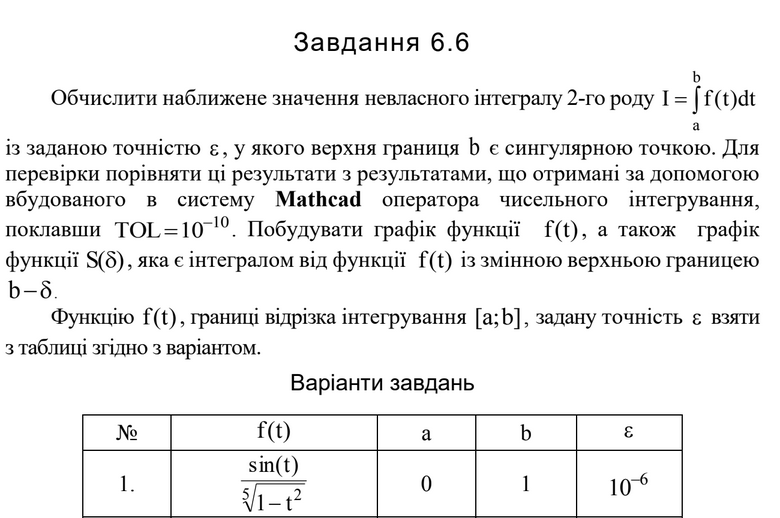

Завдання 6.6 (Варіант 1) - Невласні інтеграли 2-го роду
                         Метод  Значення інтеграла  Абсолютна похибка  Фінальний відступ (delta)
Метод зміщення границі (delta)            0.569158       5.837819e-11               4.768372e-08
       Вбудований (scipy.quad)            0.569158       2.387313e-12               0.000000e+00


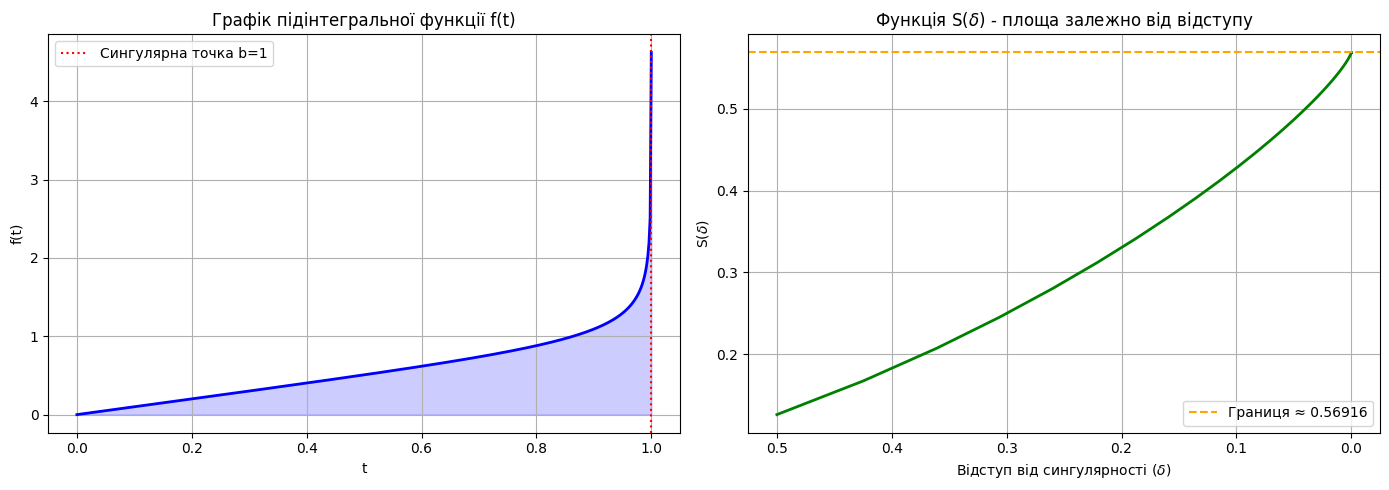

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.6, Варіант 1)
# ==========================================
a = 0.0          # Нижня границя
b = 1.0          # Верхня границя (сингулярна точка)
eps = 1e-6       # Задана точність для нашого методу
tol = 1e-10      # Точність для вбудованого оператора

def f(t):
    """Підінтегральна функція згідно з варіантом 1"""
    # Підкореневий вираз (1 - t^2) завжди додатний на [0, 1)
    return np.sin(t) / (1 - t**2)**(1/5)

# ==========================================
# 1. Алгоритм обчислення невласного інтегралу 2-го роду
# ==========================================
def improper_integral_2nd_kind(f, a, b, eps):
    """
    Поступово зменшуємо відступ (delta) від сингулярної точки b,
    поки різниця між двома ітераціями не стане меншою за eps.
    """
    delta = 0.1  # Початковий відступ
    I_prev, _ = integrate.quad(f, a, b - delta)
    
    while True:
        delta /= 2.0  # Зменшуємо відступ у 2 рази на кожному кроці
        I_curr, _ = integrate.quad(f, a, b - delta)
        
        # Перевіряємо умову досягнення потрібної точності
        if np.abs(I_curr - I_prev) < eps:
            return I_curr, delta
            
        I_prev = I_curr

I_custom, final_delta = improper_integral_2nd_kind(f, a, b, eps)

# ==========================================
# 2. Вбудований оператор (еталон)
# ==========================================
# Функція quad автоматично вміє обробляти сингулярності на кінцях відрізка
I_builtin, error = integrate.quad(f, a, b, epsabs=tol)

# ==========================================
# 3. Створення порівняльної таблиці
# ==========================================
results = {
    "Метод": [
        "Метод зміщення границі (delta)", 
        "Вбудований (scipy.quad)"
    ],
    "Значення інтеграла": [
        I_custom, 
        I_builtin
    ],
    "Абсолютна похибка": [
        np.abs(I_custom - I_builtin),
        error
    ],
    "Фінальний відступ (delta)": [
        final_delta,
        0.0 # Вбудований метод інтегрує точно до межі
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.6 (Варіант 1) - Невласні інтеграли 2-го роду")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)

# ==========================================
# 4. Побудова графіків f(t) та S(delta)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Графік 1: Підінтегральна функція f(t) ---
# Будуємо графік, не доходячи трохи до 1, щоб уникнути ділення на нуль
t_vals = np.linspace(a, b - 1e-4, 500)
f_vals = f(t_vals)

ax1.plot(t_vals, f_vals, 'b-', linewidth=2)
ax1.fill_between(t_vals, f_vals, alpha=0.2, color='blue')
# Візуалізація вертикальної асимптоти
ax1.axvline(x=b, color='red', linestyle=':', label='Сингулярна точка b=1')
ax1.set_title('Графік підінтегральної функції f(t)')
ax1.set_xlabel('t')
ax1.set_ylabel('f(t)')
ax1.legend()
ax1.grid(True)

# --- Графік 2: Функція S(delta) ---
# Генеруємо масив значень delta: від великого (0.5) до дуже маленького (final_delta)
deltas = np.logspace(np.log10(0.5), np.log10(final_delta), 100)
S_vals = [integrate.quad(f, a, b - d)[0] for d in deltas]

ax2.plot(deltas, S_vals, 'g-', linewidth=2)
ax2.axhline(y=I_builtin, color='orange', linestyle='--', label=f'Границя ≈ {I_builtin:.5f}')
ax2.set_title(r'Функція S($\delta$) - площа залежно від відступу')
ax2.set_xlabel(r'Відступ від сингулярності ($\delta$)')
ax2.set_ylabel(r'S($\delta$)')
ax2.invert_xaxis() # Інвертуємо вісь X, щоб delta прямувало до 0 зліва направо
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

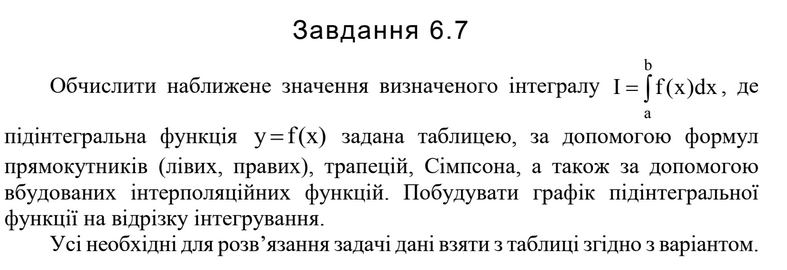

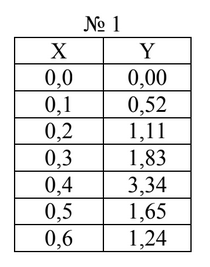

Завдання 6.7 (Варіант 1) - Інтегрування табличної функції
         Метод (таблична функція)  Значення інтеграла
                Ліві прямокутники            0.845000
               Праві прямокутники            0.969000
                         Трапеції            0.907000
                         Сімпсона            0.871333
Інтерполяція (CubicSpline + quad)            0.887804


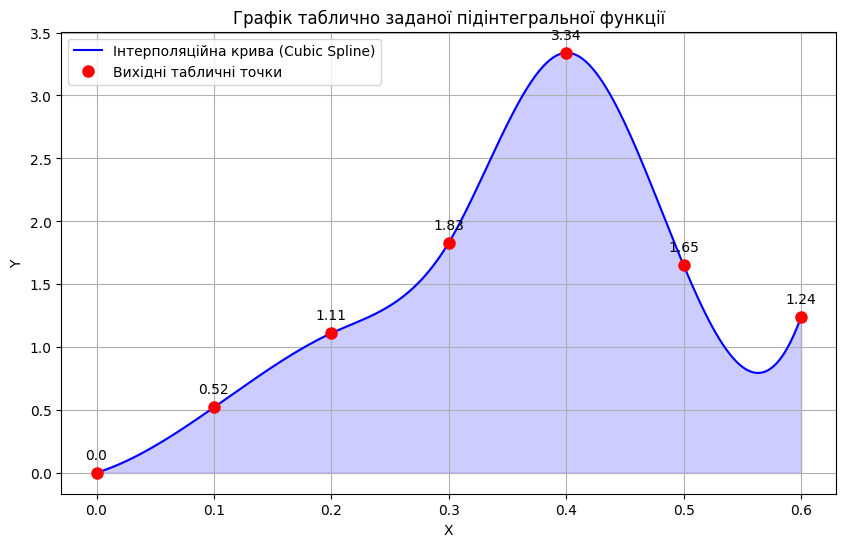

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.interpolate import CubicSpline
import pandas as pd

# ==========================================
# Вхідні дані (Завдання 6.7, Варіант 1)
# ==========================================
X = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
Y = np.array([0.00, 0.52, 1.11, 1.83, 3.34, 1.65, 1.24])

# Крок інтегрування (різниця між сусідніми X)
h = X[1] - X[0] 

# ==========================================
# 1. Формули прямокутників, трапецій та Сімпсона
# ==========================================
# Ліві прямокутники: беремо всі Y, окрім останнього
I_left = h * np.sum(Y[:-1])

# Праві прямокутники: беремо всі Y, окрім першого
I_right = h * np.sum(Y[1:])

# Формула трапецій
# I = h/2 * (Y_0 + 2*Y_1 + ... + 2*Y_n-1 + Y_n)
I_trap = (h / 2) * (Y[0] + 2 * np.sum(Y[1:-1]) + Y[-1])

# Формула Сімпсона
# I = h/3 * (Y_0 + 4*Y_непарні + 2*Y_парні + Y_n)
# Y[1:-1:2] - непарні індекси (1, 3, 5)
# Y[2:-1:2] - парні індекси (2, 4)
I_simp = (h / 3) * (Y[0] + 4 * np.sum(Y[1:-1:2]) + 2 * np.sum(Y[2:-1:2]) + Y[-1])

# ==========================================
# 2. Вбудована інтерполяційна функція
# ==========================================
# Створюємо кубічний сплайн, який плавно з'єднує всі наші точки (X, Y)
f_interp = CubicSpline(X, Y)

# Інтегруємо отриману безперервну функцію вбудованим методом quad
I_interp, error = integrate.quad(f_interp, X[0], X[-1])

# ==========================================
# 3. Порівняльна таблиця результатів
# ==========================================
results = {
    "Метод (таблична функція)": [
        "Ліві прямокутники", 
        "Праві прямокутники", 
        "Трапеції", 
        "Сімпсона", 
        "Інтерполяція (CubicSpline + quad)"
    ],
    "Значення інтеграла": [
        I_left, 
        I_right, 
        I_trap, 
        I_simp, 
        I_interp
    ]
}

df = pd.DataFrame(results)

print("Завдання 6.7 (Варіант 1) - Інтегрування табличної функції")
print("=" * 75)
print(df.to_string(index=False))
print("=" * 75)

# ==========================================
# 4. Побудова графіка
# ==========================================
# Створюємо густу сітку точок для плавного малювання інтерпольованої кривої
x_plot = np.linspace(X[0], X[-1], 200)
y_plot = f_interp(x_plot)

plt.figure(figsize=(10, 6))

# Будуємо графік плавної інтерпольованої функції
plt.plot(x_plot, y_plot, 'b-', label='Інтерполяційна крива (Cubic Spline)')
plt.fill_between(x_plot, y_plot, alpha=0.2, color='blue')

# Наносимо вихідні табличні точки
plt.plot(X, Y, 'ro', markersize=8, label='Вихідні табличні точки')

# Додаємо сітку та підписи
for i, txt in enumerate(Y):
    plt.annotate(f"{txt}", (X[i], Y[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Графік таблично заданої підінтегральної функції')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()